# Visualise posterior standard deviations

In this tutorial, we will investigate the structure of the uncertainties
returned by the probabilistic solvers. There is also the chance to compare
filters and smoothers.

In [1]:
"""Display the marginal uncertainties of filters and smoothers."""

# Set up the ODE

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from probdiffeq import ivpsolve, probdiffeq, taylor

# Fail this notebook on NaN detection (to catch those in the CI)
jax.config.update("jax_debug_nans", True)


@jax.jit
def vf(y, /, *, t):  # noqa: ARG001
    """Evaluate the Lotka-Volterra vector field."""
    y0, y1 = y[0], y[1]

    y0_new = 0.5 * y0 - 0.05 * y0 * y1
    y1_new = -0.5 * y1 + 0.05 * y0 * y1
    return jnp.asarray([y0_new, y1_new])


t0 = 0.0
t1 = 2.0
u0 = jnp.asarray([20.0, 20.0])

Set up a solver.

To all users: Try replacing the fixedpoint-smoother with a filter!

In [2]:
tcoeffs = taylor.odejet_padded_scan(lambda y: vf(y, t=t0), (u0,), num=3)
init, ssm = probdiffeq.ssm_taylor(tcoeffs, ssm_fact="blockdiag")
iwp = probdiffeq.prior_wiener_integrated(ssm=ssm)
ts = probdiffeq.constraint_ode_ts1(vf, ssm=ssm)
strategy = probdiffeq.strategy_smoother_fixedpoint(ssm=ssm)

solver = probdiffeq.solver_mle(strategy=strategy, prior=iwp, constraint=ts, ssm=ssm)
error = probdiffeq.error_residual_std(constraint=ts, prior=iwp, ssm=ssm)
solve = ivpsolve.solve_adaptive_save_at(solver=solver, error=error)

Solve the ODE.

In [3]:
ts = jnp.linspace(t0, t1, endpoint=True, num=50)
sol = jax.jit(solve)(init, save_at=ts, dt0=0.1, atol=1e-1, rtol=1e-1)

Plot the solution.

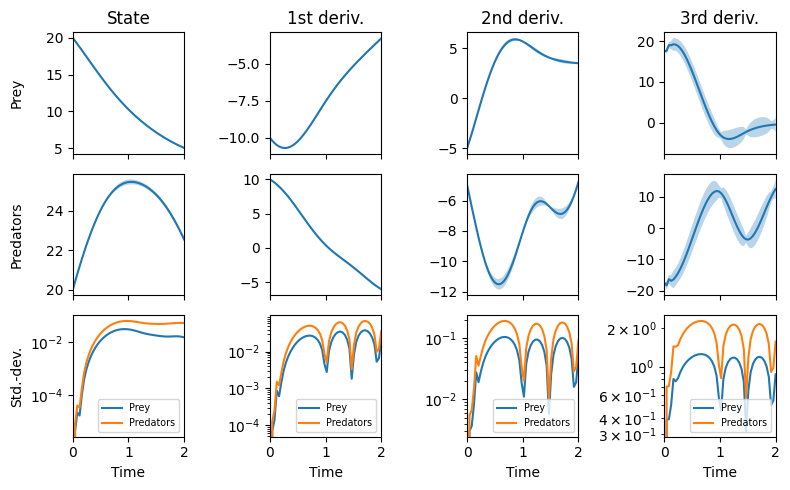

In [4]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=len(tcoeffs),
    sharex="col",
    tight_layout=True,
    figsize=(len(sol.u.mean) * 2, 5),
)
for i, (u_i, std_i, ax_i) in enumerate(zip(sol.u.mean, sol.u.std, axes.T)):
    # Set up titles and axis descriptions
    if i == 0:
        ax_i[0].set_title("State")
        ax_i[0].set_ylabel("Prey")
        ax_i[1].set_ylabel("Predators")
        ax_i[2].set_ylabel("Std.-dev.")
    elif i == 1:
        ax_i[0].set_title(f"{i}st deriv.")
    elif i == 2:
        ax_i[0].set_title(f"{i}nd deriv.")
    elif i == 3:
        ax_i[0].set_title(f"{i}rd deriv.")
    else:
        ax_i[0].set_title(f"{i}th deriv.")

    ax_i[-1].set_xlabel("Time")

    for m, std, ax in zip(u_i.T, std_i.T, ax_i):
        # Plot the mean
        ax.plot(sol.t, m)

        # Plot the standard deviation
        lower, upper = m - 1.96 * std, m + 1.96 * std
        ax.fill_between(sol.t, lower, upper, alpha=0.3)
        ax.set_xlim((jnp.amin(ts), jnp.amax(ts)))

    ax_i[2].semilogy(sol.t, std_i[:, 0], label="Prey")
    ax_i[2].semilogy(sol.t, std_i[:, 1], label="Predators")
    ax_i[2].legend(fontsize="x-small")

fig.align_ylabels()
plt.show()